# Blackrock Financial Risk Analysis
## Task 1: Data Cleaning and Formatting

In [1]:
import pandas as pd
import numpy as np

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv('blackrock.csv', dtype=str)
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")

Dataset loaded successfully!
Shape: (800, 15)


In [3]:
df.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
0,109,CUST1913,ACC64393,Credit,Withdrawal,Home Loan,Firm A,West,Manager 1,17-07-2023,47387.11457,2980.571037,0.780701036,784,170
1,19,CUST1569,ACC66190,Current,Payment,Personal Loan,Firm C,South,Manager 4,13-01-2023,55806.54015,27996.69007,0.299267659,336,197
2,14,CUST5558,ACC71426,Current,Withdrawal,Mutual Fund,Firm C,North,Manager 2,28-09-2023,51080.47837,81482.15618,0.388445047,712,95
3,107,CUST4241,ACC49422,Loan,Deposit,Credit Card,Firm D,Central,Manager 1,05-02-2023,70472.70472,39598.37194,0.561809198,414,168
4,7,CUST2578,ACC88252,Loan,Deposit,Savings Account,Firm B,East,Manager 4,19-11-2023,29830.48767,111731.9937,0.655635048,391,20


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   TransactionID      800 non-null    object
 1   CustomerID         800 non-null    object
 2   AccountID          800 non-null    object
 3   AccountType        800 non-null    object
 4   TransactionType    800 non-null    object
 5   Product            800 non-null    object
 6   Firm               800 non-null    object
 7   Region             800 non-null    object
 8   Manager            800 non-null    object
 9   TransactionDate    800 non-null    object
 10  TransactionAmount  800 non-null    object
 11  AccountBalance     800 non-null    object
 12  RiskScore          800 non-null    object
 13  CreditRating       800 non-null    object
 14  TenureMonths       800 non-null    object
dtypes: object(15)
memory usage: 93.9+ KB


In [5]:
df.isnull().sum()

TransactionID        0
CustomerID           0
AccountID            0
AccountType          0
TransactionType      0
Product              0
Firm                 0
Region               0
Manager              0
TransactionDate      0
TransactionAmount    0
AccountBalance       0
RiskScore            0
CreditRating         0
TenureMonths         0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
financial_cols = ['TransactionAmount', 'AccountBalance', 'RiskScore', 'CreditRating', 'TenureMonths']

for col in financial_cols:
    mask = df[col].str.contains(r'[^\d.\-eE]', na=False, regex=True)
    print(f"{col} - dirty entries: {mask.sum()}")

TransactionAmount - dirty entries: 0
AccountBalance - dirty entries: 0
RiskScore - dirty entries: 0
CreditRating - dirty entries: 0
TenureMonths - dirty entries: 0


In [8]:
df = df.apply(lambda col: col.str.strip())
df.columns = df.columns.str.strip().str.replace(r'\s+', '_', regex=True).str.lower()
print(df.columns.tolist())

['transactionid', 'customerid', 'accountid', 'accounttype', 'transactiontype', 'product', 'firm', 'region', 'manager', 'transactiondate', 'transactionamount', 'accountbalance', 'riskscore', 'creditrating', 'tenuremonths']


In [9]:
df['transactionamount'] = pd.to_numeric(df['transactionamount'], errors='coerce')
df['accountbalance']    = pd.to_numeric(df['accountbalance'],    errors='coerce')
df['riskscore']         = pd.to_numeric(df['riskscore'],         errors='coerce')
df['creditrating']      = pd.to_numeric(df['creditrating'],      errors='coerce').astype('Int64')
df['tenuremonths']      = pd.to_numeric(df['tenuremonths'],      errors='coerce').astype('Int64')
df['transactionid']     = pd.to_numeric(df['transactionid'],     errors='coerce').astype('Int64')
print("Numeric conversion done!")

Numeric conversion done!


In [10]:
df['transactiondate'] = pd.to_datetime(df['transactiondate'], dayfirst=True, errors='coerce')
print(df['transactiondate'].dtype)

datetime64[ns]


In [11]:
cat_cols = ['accounttype', 'transactiontype', 'product', 'firm', 'region', 'manager']
for col in cat_cols:
    df[col] = df[col].str.title()
print("Categorical columns standardised!")

Categorical columns standardised!


In [12]:
print("Negative TransactionAmount:", (df['transactionamount'] < 0).sum())
print("Negative RiskScore:", (df['riskscore'] < 0).sum())
print("Negative AccountBalance (Overdrafts):", (df['accountbalance'] < 0).sum())

df['transactionamount'] = df['transactionamount'].abs()
df['riskscore'] = df['riskscore'].abs()
df['overdraft_flag'] = df['accountbalance'] < 0
print("Done!")

Negative TransactionAmount: 29
Negative RiskScore: 19
Negative AccountBalance (Overdrafts): 18
Done!


In [13]:
print(df.shape)
print(df.dtypes)
df.head()

(800, 16)
transactionid                 Int64
customerid                   object
accountid                    object
accounttype                  object
transactiontype              object
product                      object
firm                         object
region                       object
manager                      object
transactiondate      datetime64[ns]
transactionamount           float64
accountbalance              float64
riskscore                   float64
creditrating                  Int64
tenuremonths                  Int64
overdraft_flag                 bool
dtype: object


,transactionid,customerid,accountid,accounttype,transactiontype,product,firm,region,manager,transactiondate,transactionamount,accountbalance,riskscore,creditrating,tenuremonths,overdraft_flag
0,109,CUST1913,ACC64393,Credit,Withdrawal,Home Loan,Firm A,West,Manager 1,2023-07-17,47387.11457,2980.571037,0.780701,784,170,False
1,19,CUST1569,ACC66190,Current,Payment,Personal Loan,Firm C,South,Manager 4,2023-01-13,55806.54015,27996.690070,0.299268,336,197,False
2,14,CUST5558,ACC71426,Current,Withdrawal,Mutual Fund,Firm C,North,Manager 2,2023-09-28,51080.47837,81482.156180,0.388445,712,95,False
3,107,CUST4241,ACC49422,Loan,Deposit,Credit Card,Firm D,Central,Manager 1,2023-02-05,70472.70472,39598.371940,0.561809,414,168,False
4,7,CUST2578,ACC88252,Loan,Deposit,Savings Account,Firm B,East,Manager 4,2023-11-19,29830.48767,111731.993700,0.655635,391,20,False


In [14]:
print(df[['transactionamount', 'accountbalance']].dtypes)
print()
print(df[['transactionamount', 'accountbalance']].head())

transactionamount    float64
accountbalance       float64
dtype: object

   transactionamount  accountbalance
0        47387.11457     2980.571037
1        55806.54015    27996.690070
2        51080.47837    81482.156180
3        70472.70472    39598.371940
4        29830.48767   111731.993700


In [15]:
print(df['transactiondate'].dtype)
print(df['transactiondate'].isnull().sum())
print(df['transactiondate'].head())

datetime64[ns]
0
0   2023-07-17
1   2023-01-13
2   2023-09-28
3   2023-02-05
4   2023-11-19
Name: transactiondate, dtype: datetime64[ns]


In [16]:
df['transaction_year']  = df['transactiondate'].dt.year
df['transaction_month'] = df['transactiondate'].dt.month
df['transaction_day']   = df['transactiondate'].dt.day

print(df[['transactiondate', 'transaction_year', 'transaction_month', 'transaction_day']].head())

  transactiondate  transaction_year  transaction_month  transaction_day
0      2023-07-17              2023                  7               17
1      2023-01-13              2023                  1               13
2      2023-09-28              2023                  9               28
3      2023-02-05              2023                  2                5
4      2023-11-19              2023                 11               19


In [17]:
print("AccountType:", df['accounttype'].unique())
print("TransactionType:", df['transactiontype'].unique())
print("Product:", df['product'].unique())

AccountType: ['Credit' 'Current' 'Loan' 'Savings']
TransactionType: ['Withdrawal' 'Payment' 'Deposit' 'Transfer']
Product: ['Home Loan' 'Personal Loan' 'Mutual Fund' 'Credit Card' 'Savings Account']


In [18]:
df['accounttype']     = df['accounttype'].str.strip().str.title()
df['transactiontype'] = df['transactiontype'].str.strip().str.title()
df['product']         = df['product'].str.strip().str.title()

print("AccountType:", df['accounttype'].unique())
print("TransactionType:", df['transactiontype'].unique())
print("Product:", df['product'].unique())

AccountType: ['Credit' 'Current' 'Loan' 'Savings']
TransactionType: ['Withdrawal' 'Payment' 'Deposit' 'Transfer']
Product: ['Home Loan' 'Personal Loan' 'Mutual Fund' 'Credit Card' 'Savings Account']


Task 2: Descriptive Transactional Analysis

In [19]:
df['transaction_category'] = df['transactiontype'].apply(
    lambda x: 'Credit' if x == 'Deposit' else 'Debit'
)
print(df['transaction_category'].value_counts())

transaction_category
Debit     618
Credit    182
Name: count, dtype: int64


In [20]:
monthly_summary = df.groupby(['transaction_year', 'transaction_month', 'transaction_category'])['transactionamount'].sum().unstack(fill_value=0)
monthly_summary['Net_Volume'] = monthly_summary.get('Credit', 0) - monthly_summary.get('Debit', 0)
print(monthly_summary)

transaction_category                      Credit         Debit    Net_Volume
transaction_year transaction_month                                          
2023             1                  4.532878e+05  1.832379e+06 -1.379091e+06
                 2                  5.565913e+05  2.610104e+06 -2.053512e+06
                 3                  4.224074e+05  1.913691e+06 -1.491284e+06
                 4                  3.432981e+05  1.849189e+06 -1.505891e+06
                 5                  9.335588e+05  2.360638e+06 -1.427079e+06
                 6                  6.760825e+05  1.106279e+06 -4.301961e+05
                 7                  4.865498e+05  1.429469e+06 -9.429193e+05
                 8                  8.198514e+04  2.005869e+06 -1.923884e+06
                 9                  7.491474e+05  2.195770e+06 -1.446623e+06
                 10                 1.322052e+06  2.846267e+06 -1.524216e+06
                 11                 9.661783e+05  1.984515e+06 -1.018337e+06

In [21]:
yearly_summary = df.groupby(['transaction_year', 'transaction_category'])['transactionamount'].sum().unstack(fill_value=0)
yearly_summary['Net_Volume'] = yearly_summary.get('Credit', 0) - yearly_summary.get('Debit', 0)
print(yearly_summary)

transaction_category        Credit         Debit    Net_Volume
transaction_year                                              
2023                  7.514000e+06  2.333827e+07 -1.582427e+07
2024                  3.349771e+06  1.004174e+07 -6.691971e+06


In [23]:
import matplotlib.pyplot as plt

In [25]:
monthly_trend = df.groupby(['transaction_year', 'transaction_month', 'transaction_category'])['transactionamount'].sum().reset_index()
monthly_trend['period'] = pd.to_datetime(monthly_trend[['transaction_year', 'transaction_month']].assign(day=1).rename(columns={'transaction_year':'year','transaction_month':'month'}))

credits = monthly_trend[monthly_trend['transaction_category'] == 'Credit']
debits  = monthly_trend[monthly_trend['transaction_category'] == 'Debit']

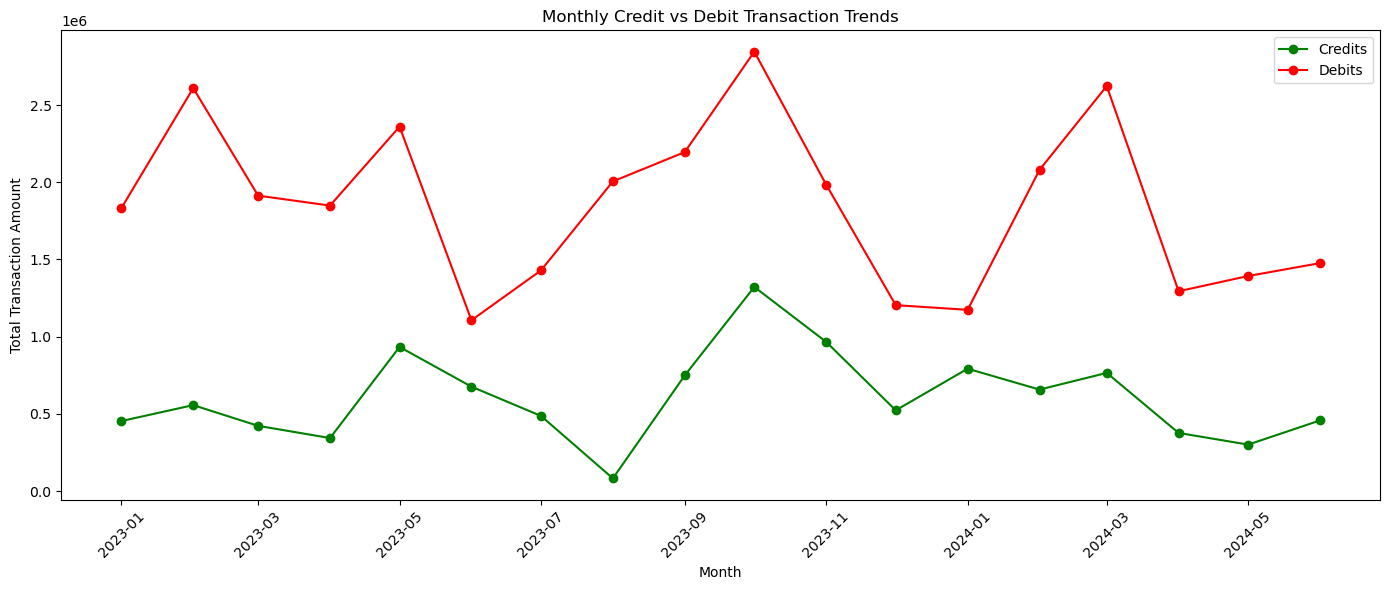

In [26]:
plt.figure(figsize=(14, 6))
plt.plot(credits['period'], credits['transactionamount'], marker='o', color='green', label='Credits')
plt.plot(debits['period'],  debits['transactionamount'],  marker='o', color='red',   label='Debits')
plt.title('Monthly Credit vs Debit Transaction Trends')
plt.xlabel('Month')
plt.ylabel('Total Transaction Amount')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
df['signed_amount'] = df.apply(
    lambda row: row['transactionamount'] if row['transaction_category'] == 'Credit' 
    else -row['transactionamount'], axis=1
)

net_inflow = df.groupby('accountid')['signed_amount'].sum().reset_index()
net_inflow.columns = ['accountid', 'net_inflow']
net_inflow = net_inflow.sort_values('net_inflow', ascending=False)
print(f"Total accounts: {len(net_inflow)}")

Total accounts: 192


In [28]:
top10 = net_inflow.head(10)
print("=== TOP 10 Accounts (Highest Net Inflow) ===")
print(top10.to_string(index=False))

=== TOP 10 Accounts (Highest Net Inflow) ===
accountid    net_inflow
 ACC88286 284230.600790
 ACC21719 253560.286240
 ACC51200 201469.732440
 ACC28295 199450.692920
 ACC83269 180850.726890
 ACC88252 179626.224033
 ACC88449 106297.066460
 ACC32627  96600.216110
 ACC18177  94801.131690
 ACC99117  92159.600750


In [29]:
bottom10 = net_inflow.tail(10)
print("=== BOTTOM 10 Accounts (Lowest Net Inflow) ===")
print(bottom10.to_string(index=False))

=== BOTTOM 10 Accounts (Lowest Net Inflow) ===
accountid     net_inflow
 ACC71938 -353666.209440
 ACC95774 -357669.637940
 ACC78581 -361217.173349
 ACC35419 -365901.203200
 ACC81631 -380211.087960
 ACC52650 -387133.819950
 ACC77592 -397721.376701
 ACC70460 -432195.230130
 ACC45101 -440747.603790
 ACC97411 -454306.215953


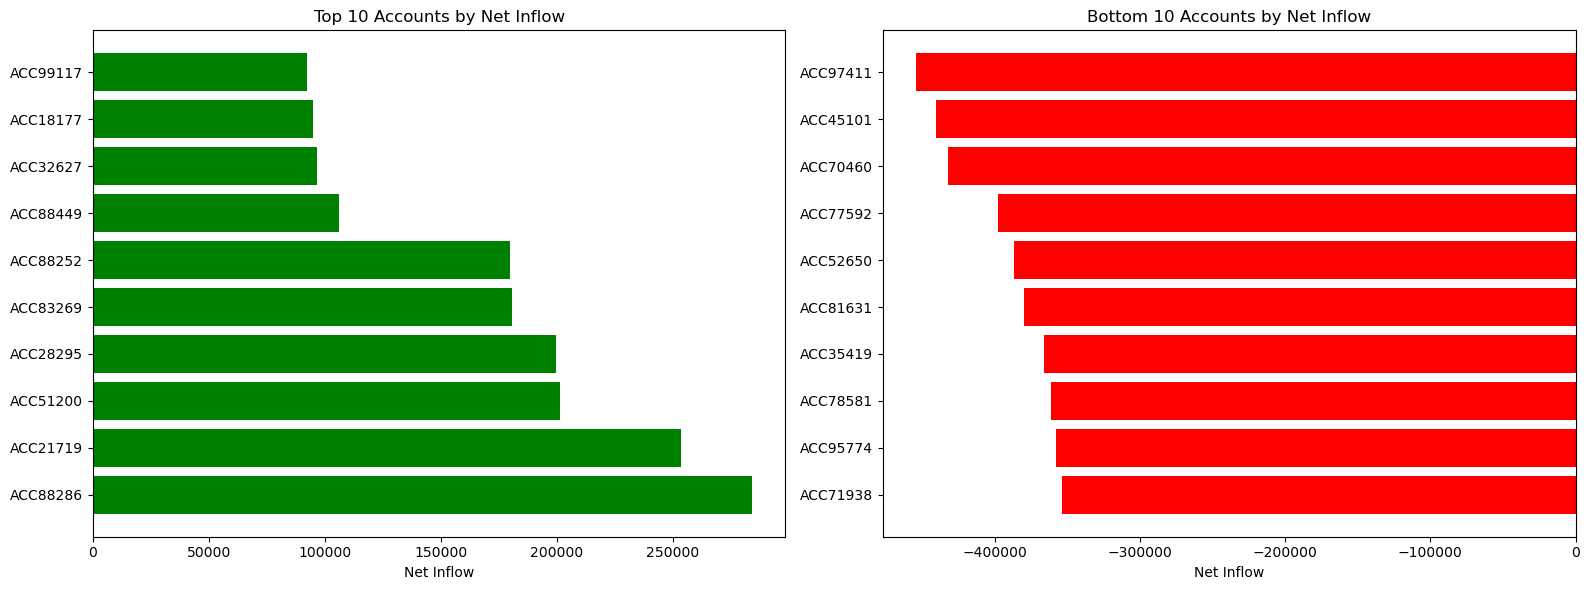

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top10['accountid'], top10['net_inflow'], color='green')
axes[0].set_title('Top 10 Accounts by Net Inflow')
axes[0].set_xlabel('Net Inflow')

axes[1].barh(bottom10['accountid'], bottom10['net_inflow'], color='red')
axes[1].set_title('Bottom 10 Accounts by Net Inflow')
axes[1].set_xlabel('Net Inflow')

plt.tight_layout()
plt.show()

In [31]:
df_sorted = df.sort_values(['accountid', 'transactiondate'])
df_sorted['prev_transaction_date'] = df_sorted.groupby('accountid')['transactiondate'].shift(1)
df_sorted['days_gap'] = (df_sorted['transactiondate'] - df_sorted['prev_transaction_date']).dt.days
print(df_sorted[['accountid', 'transactiondate', 'prev_transaction_date', 'days_gap']].head(10))

    accountid transactiondate prev_transaction_date  days_gap
549  ACC10117      2023-09-13                   NaT       NaN
301  ACC10117      2023-09-28            2023-09-13      15.0
724  ACC10117      2023-12-09            2023-09-28      72.0
787  ACC10117      2023-12-30            2023-12-09      21.0
27   ACC10117      2024-01-12            2023-12-30      13.0
547  ACC10117      2024-04-25            2024-01-12     104.0
69   ACC10996      2023-01-21                   NaT       NaN
162  ACC10996      2023-02-05            2023-01-21      15.0
144  ACC10996      2023-06-19            2023-02-05     134.0
491  ACC10996      2023-10-06            2023-06-19     109.0


In [32]:
dormant_accounts = df_sorted[df_sorted['days_gap'] >= 60]['accountid'].unique()
df['dormant_flag'] = df['accountid'].isin(dormant_accounts)

print(f"Total dormant/inactive accounts: {df['dormant_flag'].sum()}")
print(f"Unique dormant accounts: {len(dormant_accounts)}")

Total dormant/inactive accounts: 762
Unique dormant accounts: 172


In [33]:
dormant_summary = df[df['dormant_flag'] == True][['accountid', 'customerid', 'accounttype', 'transactiondate']].drop_duplicates('accountid')
print(dormant_summary.head(10).to_string(index=False))

accountid customerid accounttype transactiondate
 ACC64393   CUST1913      Credit      2023-07-17
 ACC66190   CUST1569     Current      2023-01-13
 ACC71426   CUST5558     Current      2023-09-28
 ACC49422   CUST4241        Loan      2023-02-05
 ACC88252   CUST2578        Loan      2023-11-19
 ACC35419   CUST5664        Loan      2023-05-24
 ACC16241   CUST7855        Loan      2024-02-21
 ACC11062   CUST6210     Savings      2023-02-14
 ACC57700   CUST1121      Credit      2024-03-23
 ACC92360   CUST9564     Savings      2023-03-07


Task 3: Customer Profile Building

In [34]:
txn_frequency = df.groupby('accountid')['transactionid'].count().reset_index()
txn_frequency.columns = ['accountid', 'txn_count']
print(txn_frequency['txn_count'].describe())

count       192.0
mean     4.166667
std      2.021697
min           1.0
25%           3.0
50%           4.0
75%           5.0
max          13.0
Name: txn_count, dtype: Float64


In [35]:
def assign_activity(count):
    if count >= 6:
        return 'High'
    elif count >= 3:
        return 'Medium'
    else:
        return 'Low'

txn_frequency['activity_level'] = txn_frequency['txn_count'].apply(assign_activity)
print(txn_frequency['activity_level'].value_counts())

activity_level
Medium    105
High       45
Low        42
Name: count, dtype: int64


In [36]:
df = df.merge(txn_frequency[['accountid', 'txn_count', 'activity_level']], on='accountid', how='left')
print(df[['accountid', 'txn_count', 'activity_level']].drop_duplicates('accountid').head(10).to_string(index=False))

accountid  txn_count activity_level
 ACC64393          4         Medium
 ACC66190          4         Medium
 ACC71426          6           High
 ACC49422          5         Medium
 ACC88252          5         Medium
 ACC35419          6           High
 ACC16241          9           High
 ACC11062          6           High
 ACC57700          8           High
 ACC55729          4         Medium


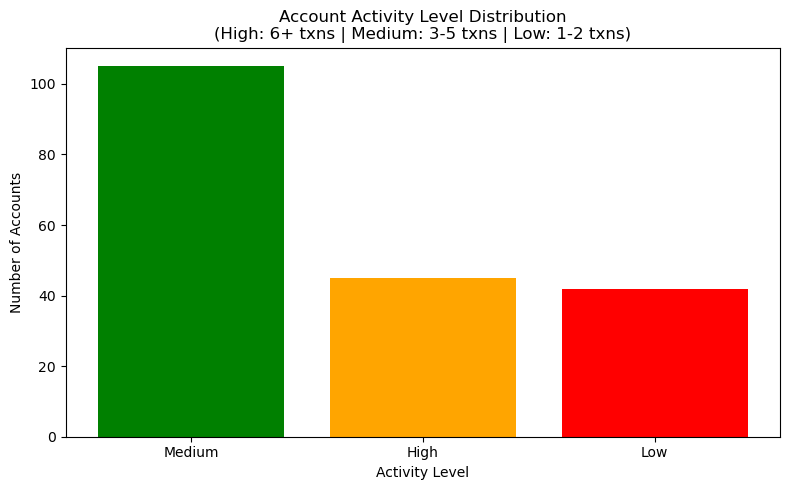

In [37]:
activity_counts = txn_frequency['activity_level'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(activity_counts.index, activity_counts.values, color=['green', 'orange', 'red'])
plt.title('Account Activity Level Distribution\n(High: 6+ txns | Medium: 3-5 txns | Low: 1-2 txns)')
plt.xlabel('Activity Level')
plt.ylabel('Number of Accounts')
plt.tight_layout()
plt.show()

In [38]:
customer_segment = df.groupby('customerid').agg(
    avg_balance=('accountbalance', 'mean'),
    avg_txn_volume=('transactionamount', 'mean')
).reset_index()
print(customer_segment.describe())

         avg_balance  avg_txn_volume
count     180.000000      180.000000
mean    72602.144517    55755.320978
std     19475.215759    14219.452130
min      4873.356091    23654.562502
25%     62003.627212    45635.074515
50%     72510.355527    56148.962174
75%     85062.282137    63628.784513
max    137652.013500   111333.477800


In [39]:
def assign_segment(row):
    if row['avg_balance'] > 90000 and row['avg_txn_volume'] > 70000:
        return 'Premium'
    elif row['avg_balance'] >= 50000 and row['avg_txn_volume'] >= 40000:
        return 'Standard'
    else:
        return 'Basic'

customer_segment['segment'] = customer_segment.apply(assign_segment, axis=1)
print(customer_segment['segment'].value_counts())

segment
Standard    130
Basic        41
Premium       9
Name: count, dtype: int64


In [40]:
df = df.merge(customer_segment[['customerid', 'avg_balance', 'avg_txn_volume', 'segment']], on='customerid', how='left')
print(df[['customerid', 'avg_balance', 'avg_txn_volume', 'segment']].drop_duplicates('customerid').head(10).to_string(index=False))

customerid  avg_balance  avg_txn_volume  segment
  CUST1913 53031.790335    47821.095932 Standard
  CUST1569 55028.817944    42189.673634 Standard
  CUST5558 62072.907250    42017.855910 Standard
  CUST4241 84307.548772    63252.519436 Standard
  CUST2578 75563.876932    58508.532472 Standard
  CUST5664 97409.985772    50025.743064 Standard
  CUST7855 79020.956278    56370.850042 Standard
  CUST6210 21030.369426    53414.872450    Basic
  CUST1121 63924.640954    56262.960652 Standard
  CUST2626 51929.887144    47488.428896 Standard


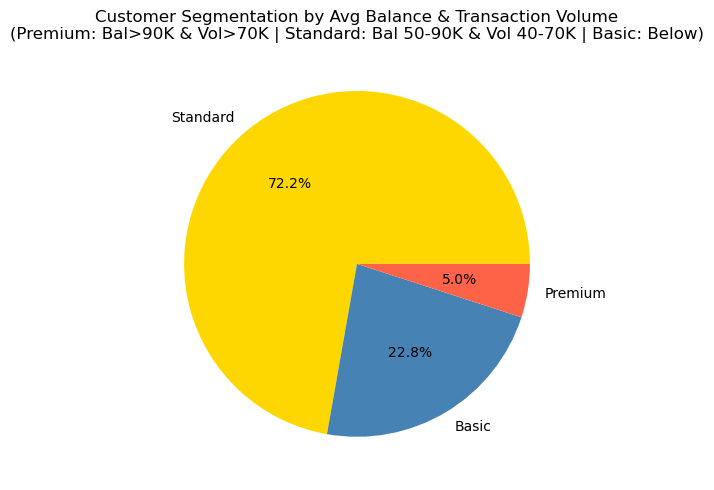

In [41]:
segment_counts = customer_segment['segment'].value_counts()

plt.figure(figsize=(8, 5))
plt.pie(segment_counts.values, labels=segment_counts.index, autopct='%1.1f%%',
        colors=['gold', 'steelblue', 'tomato'])
plt.title('Customer Segmentation by Avg Balance & Transaction Volume\n(Premium: Bal>90K & Vol>70K | Standard: Bal 50-90K & Vol 40-70K | Basic: Below)')
plt.tight_layout()
plt.show()

In [42]:
net_inflow_profile = df.groupby('accountid').agg(
    net_inflow=('signed_amount', 'sum'),
    avg_balance=('accountbalance', 'mean'),
    txn_count=('transactionid', 'count'),
    account_type=('accounttype', 'first'),
    region=('region', 'first')
).reset_index()

threshold = net_inflow_profile['net_inflow'].quantile(0.90)
high_net_inflow = net_inflow_profile[net_inflow_profile['net_inflow'] >= threshold]
print(f"High Net Inflow Threshold (90th percentile): {threshold:,.2f}")
print(f"Total High Net Inflow Accounts: {len(high_net_inflow)}")
print(high_net_inflow.sort_values('net_inflow', ascending=False).to_string(index=False))

High Net Inflow Threshold (90th percentile): 55,893.97
Total High Net Inflow Accounts: 20
accountid    net_inflow   avg_balance  txn_count account_type  region
 ACC88286 284230.600790  71284.188672          5      Current   North
 ACC21719 253560.286240  72818.112908          4      Current   North
 ACC51200 201469.732440  72388.011257          4       Credit    West
 ACC28295 199450.692920 125043.309138          4       Credit   South
 ACC83269 180850.726890  93528.522860          2         Loan    East
 ACC88252 179626.224033  86094.900381          5         Loan    East
 ACC88449 106297.066460  65416.355338          5       Credit Central
 ACC32627  96600.216110  93374.434050          4       Credit    West
 ACC18177  94801.131690  67026.629560          3       Credit    West
 ACC99117  92159.600750 106391.248100          1       Credit   North
 ACC31902  84373.160980  65027.572310          2      Current Central
 ACC49395  81959.151390  60486.256503          3       Credit    East


In [43]:
freq_balance_profile = df.groupby('accountid').agg(
    txn_count=('transactionid', 'count'),
    avg_balance=('accountbalance', 'mean'),
    account_type=('accounttype', 'first'),
    region=('region', 'first')
).reset_index()

freq_threshold   = freq_balance_profile['txn_count'].quantile(0.75)
bal_threshold    = freq_balance_profile['avg_balance'].quantile(0.25)

high_freq_low_bal = freq_balance_profile[
    (freq_balance_profile['txn_count'] >= freq_threshold) &
    (freq_balance_profile['avg_balance'] <= bal_threshold)
]
print(f"Frequency Threshold (75th percentile): {freq_threshold}")
print(f"Balance Threshold (25th percentile):   {bal_threshold:,.2f}")
print(f"Total High Frequency Low Balance Accounts: {len(high_freq_low_bal)}")
print(high_freq_low_bal.sort_values('txn_count', ascending=False).to_string(index=False))

Frequency Threshold (75th percentile): 5.0
Balance Threshold (25th percentile):   63,455.06
Total High Frequency Low Balance Accounts: 15
accountid  txn_count  avg_balance account_type  region
 ACC41829         13 61628.656517      Savings    West
 ACC34431          8 55556.756888      Current    East
 ACC43771          8 59242.759106         Loan    East
 ACC96277          8 53257.609105      Current    West
 ACC45521          7 49875.368013      Savings Central
 ACC76597          7 56524.016080      Current    West
 ACC78581          7 60382.951011      Current   North
 ACC11062          6 57108.763888      Savings   North
 ACC35419          6 53390.330235         Loan   South
 ACC61827          6 47266.088053      Savings   North
 ACC77638          6 54284.430696       Credit   North
 ACC92360          6 56191.522772      Savings   South
 ACC24070          5 53811.388618       Credit    West
 ACC42710          5 63115.146550         Loan    East
 ACC48501          5 53845.585612    

In [44]:
near_zero_threshold = 1000

neg_near_zero = df.groupby('accountid').agg(
    avg_balance=('accountbalance', 'mean'),
    min_balance=('accountbalance', 'min'),
    txn_count=('transactionid', 'count'),
    account_type=('accounttype', 'first'),
    overdraft=('overdraft_flag', 'any')
).reset_index()

neg_near_zero = neg_near_zero[neg_near_zero['avg_balance'] <= near_zero_threshold]
print(f"Near-Zero Balance Threshold: ₹{near_zero_threshold}")
print(f"Total Negative/Near-Zero Balance Accounts: {len(neg_near_zero)}")
print(neg_near_zero.sort_values('avg_balance').to_string(index=False))

Near-Zero Balance Threshold: ₹1000
Total Negative/Near-Zero Balance Accounts: 0
Empty DataFrame
Columns: [accountid, avg_balance, min_balance, txn_count, account_type, overdraft]
Index: []


In [45]:
print("=========================================")
print("       CUSTOMER PROFILE SUMMARY          ")
print("=========================================")
print(f"Profile A - High Net Inflow Accounts      : {len(high_net_inflow)} accounts")
print(f"Profile B - High Frequency Low Balance    : {len(high_freq_low_bal)} accounts")
print(f"Profile C - Negative/Near-Zero Balance    : {len(neg_near_zero)} accounts")
print("=========================================")

       CUSTOMER PROFILE SUMMARY          
Profile A - High Net Inflow Accounts      : 20 accounts
Profile B - High Frequency Low Balance    : 15 accounts
Profile C - Negative/Near-Zero Balance    : 0 accounts


Task 4: Financial Risk Identification

In [46]:
withdrawals = df[df['transactiontype'].isin(['Withdrawal', 'Payment', 'Transfer'])]
large_withdrawal_threshold = withdrawals['transactionamount'].quantile(0.75)
print(f"Large Withdrawal Threshold (75th percentile): ₹{large_withdrawal_threshold:,.2f}")

Large Withdrawal Threshold (75th percentile): ₹72,196.24


In [47]:
large_withdrawals = withdrawals[withdrawals['transactionamount'] >= large_withdrawal_threshold]

freq_large_withdrawals = large_withdrawals.groupby('accountid')['transactionid'].count().reset_index()
freq_large_withdrawals.columns = ['accountid', 'large_withdrawal_count']

risky_withdrawal_accounts = freq_large_withdrawals[freq_large_withdrawals['large_withdrawal_count'] >= 3]
print(f"Accounts with Frequent Large Withdrawals: {len(risky_withdrawal_accounts)}")
print(risky_withdrawal_accounts.sort_values('large_withdrawal_count', ascending=False).to_string(index=False))

Accounts with Frequent Large Withdrawals: 10
accountid  large_withdrawal_count
 ACC77638                       4
 ACC10996                       3
 ACC24070                       3
 ACC29007                       3
 ACC35419                       3
 ACC45101                       3
 ACC62446                       3
 ACC71938                       3
 ACC77592                       3
 ACC81631                       3


In [48]:
overdraft_accounts = df[df['overdraft_flag'] == True][['accountid', 'customerid', 'accounttype', 'accountbalance', 'transactiondate']].sort_values('accountbalance')
print(f"Total Overdraft Records: {len(overdraft_accounts)}")
print(f"Unique Overdraft Accounts: {overdraft_accounts['accountid'].nunique()}")
print(overdraft_accounts.head(10).to_string(index=False))

Total Overdraft Records: 18
Unique Overdraft Accounts: 17
accountid customerid accounttype  accountbalance transactiondate
 ACC39529   CUST6565     Savings   -35891.001750      2023-02-05
 ACC34821   CUST3315     Savings   -32532.523740      2023-02-04
 ACC46953   CUST9731        Loan   -26968.230900      2023-10-24
 ACC78589   CUST2578      Credit   -25971.512010      2023-09-06
 ACC45521   CUST1962     Savings   -18963.797190      2023-10-22
 ACC64022   CUST3153        Loan   -11356.975610      2024-01-29
 ACC88516   CUST9843     Savings    -9208.204563      2023-01-13
 ACC11062   CUST6210     Savings    -9084.224009      2023-02-14
 ACC74631   CUST6210     Savings    -8820.480676      2023-01-08
 ACC15671   CUST5610     Savings    -8225.602340      2024-02-05


In [49]:
df['frequent_large_withdrawal_flag'] = df['accountid'].isin(risky_withdrawal_accounts['accountid'])

risk_summary = df.groupby('accountid').agg(
    overdraft=('overdraft_flag', 'any'),
    frequent_large_withdrawal=('frequent_large_withdrawal_flag', 'any'),
    avg_balance=('accountbalance', 'mean'),
    txn_count=('transactionid', 'count')
).reset_index()

risk_summary['at_risk'] = risk_summary['overdraft'] | risk_summary['frequent_large_withdrawal']
print(f"Total At-Risk Accounts: {risk_summary['at_risk'].sum()}")
print(risk_summary[risk_summary['at_risk'] == True].sort_values('avg_balance').head(10).to_string(index=False))

Total At-Risk Accounts: 26
accountid  overdraft  frequent_large_withdrawal  avg_balance  txn_count  at_risk
 ACC34821       True                      False 23319.336055          4     True
 ACC15671       True                      False 27077.566847          3     True
 ACC78589       True                      False 34272.665816          3     True
 ACC46953       True                      False 35656.159735          2     True
 ACC87602       True                      False 41022.300481          3     True
 ACC88516       True                      False 41461.224302          4     True
 ACC45521       True                      False 49875.368013          7     True
 ACC35419      False                       True 53390.330235          6     True
 ACC97225       True                      False 53496.777053          3     True
 ACC24070      False                       True 53811.388618          5     True


In [50]:
volatility = df.groupby('accountid')['accountbalance'].agg(
    mean_balance='mean',
    std_balance='std'
).reset_index()

volatility['cv'] = (volatility['std_balance'] / volatility['mean_balance'].abs()) * 100
volatility = volatility.dropna(subset=['cv'])
print(volatility.describe())

        mean_balance   std_balance          cv
count     184.000000    184.000000  184.000000
mean    73175.029220  30746.744279   46.068516
std     18338.723919  16582.277290   34.873800
min     23319.336055    791.574703    1.066368
25%     63056.261115  18377.109212   25.547863
50%     72310.118753  29221.079624   38.868781
75%     83496.490262  40074.992913   56.774379
max    130695.134600  91165.113157  252.163483


In [51]:
cv_75 = volatility['cv'].quantile(0.75)
cv_25 = volatility['cv'].quantile(0.25)

print(f"CV 75th Percentile (High threshold) : {cv_75:.2f}%")
print(f"CV 25th Percentile (Low threshold)  : {cv_25:.2f}%")

def classify_volatility(cv):
    if cv >= cv_75:
        return 'High'
    elif cv >= cv_25:
        return 'Medium'
    else:
        return 'Low'

volatility['volatility_level'] = volatility['cv'].apply(classify_volatility)
print(volatility['volatility_level'].value_counts())

CV 75th Percentile (High threshold) : 56.77%
CV 25th Percentile (Low threshold)  : 25.55%
volatility_level
Medium    92
Low       46
High      46
Name: count, dtype: int64


In [52]:
print("=== Top 10 Most Volatile Accounts ===")
print(volatility.sort_values('cv', ascending=False).head(10).to_string(index=False))

=== Top 10 Most Volatile Accounts ===
accountid  mean_balance  std_balance         cv volatility_level
 ACC78589  34272.665816 86423.147835 252.163483             High
 ACC46953  35656.159735 88564.262571 248.384187             High
 ACC34821  23319.336055 48974.249807 210.015627             High
 ACC39529  62774.934093 91165.113157 145.225343             High
 ACC15671  27077.566847 30995.763211 114.470268             High
 ACC87602  41022.300481 46348.764739 112.984314             High
 ACC38559  66090.737960 70149.365923 106.140994             High
 ACC28612  42258.706897 44658.868241 105.679685             High
 ACC97225  53496.777053 51171.428405  95.653292             High
 ACC76699  46970.955587 44554.662869  94.855773             High


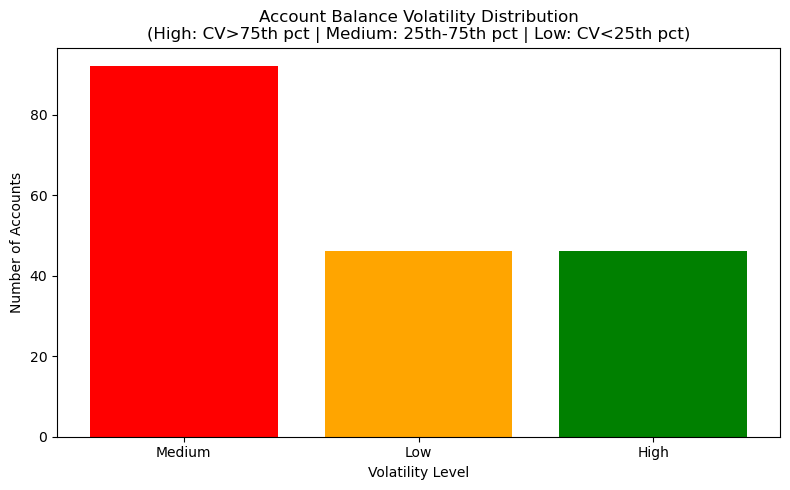

In [53]:
df = df.merge(volatility[['accountid', 'std_balance', 'cv', 'volatility_level']], on='accountid', how='left')

volatility_counts = volatility['volatility_level'].value_counts()
plt.figure(figsize=(8, 5))
plt.bar(volatility_counts.index, volatility_counts.values, color=['red', 'orange', 'green'])
plt.title('Account Balance Volatility Distribution\n(High: CV>75th pct | Medium: 25th-75th pct | Low: CV<25th pct)')
plt.xlabel('Volatility Level')
plt.ylabel('Number of Accounts')
plt.tight_layout()
plt.show()

In [54]:
Q1  = df['transactionamount'].quantile(0.25)
Q3  = df['transactionamount'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: ₹{Q1:,.2f} | Q3: ₹{Q3:,.2f} | IQR: ₹{IQR:,.2f}")
print(f"Lower Bound: ₹{lower_bound:,.2f}")
print(f"Upper Bound: ₹{upper_bound:,.2f}")

df['iqr_anomaly'] = (df['transactionamount'] < lower_bound) | (df['transactionamount'] > upper_bound)
print(f"\nIQR Anomalies Detected: {df['iqr_anomaly'].sum()}")

Q1: ₹34,600.68 | Q3: ₹73,485.55 | IQR: ₹38,884.87
Lower Bound: ₹-23,726.62
Upper Bound: ₹131,812.85

IQR Anomalies Detected: 5


In [55]:
from scipy import stats

df['zscore_transactionamount'] = stats.zscore(df['transactionamount'])
df['zscore_anomaly'] = df['zscore_transactionamount'].abs() > 3

print(f"Z-Score Anomalies Detected: {df['zscore_anomaly'].sum()}")
print(df[df['zscore_anomaly'] == True][['accountid', 'customerid', 'transactionamount', 'zscore_transactionamount']].to_string(index=False))

Z-Score Anomalies Detected: 4
accountid customerid  transactionamount  zscore_transactionamount
 ACC21719   CUST2443        155241.4276                  3.552382
 ACC18057   CUST4780        144421.8432                  3.167785
 ACC41829   CUST6565        144271.2717                  3.162433
 ACC45101   CUST1888        165004.5369                  3.899424


In [56]:
df['anomaly_flag'] = df['iqr_anomaly'] | df['zscore_anomaly']

print(f"Total Anomalous Transactions (Either Method) : {df['anomaly_flag'].sum()}")
print(f"IQR Only                                     : {(df['iqr_anomaly'] & ~df['zscore_anomaly']).sum()}")
print(f"Z-Score Only                                 : {(df['zscore_anomaly'] & ~df['iqr_anomaly']).sum()}")
print(f"Both Methods                                 : {(df['iqr_anomaly'] & df['zscore_anomaly']).sum()}")
print()
print(df[df['anomaly_flag'] == True][['accountid', 'customerid', 'transactionamount', 'iqr_anomaly', 'zscore_anomaly']].sort_values('transactionamount', ascending=False).head(10).to_string(index=False))

Total Anomalous Transactions (Either Method) : 5
IQR Only                                     : 1
Z-Score Only                                 : 0
Both Methods                                 : 4

accountid customerid  transactionamount  iqr_anomaly  zscore_anomaly
 ACC45101   CUST1888        165004.5369         True            True
 ACC21719   CUST2443        155241.4276         True            True
 ACC18057   CUST4780        144421.8432         True            True
 ACC41829   CUST6565        144271.2717         True            True
 ACC83848   CUST1042        137999.1893         True           False


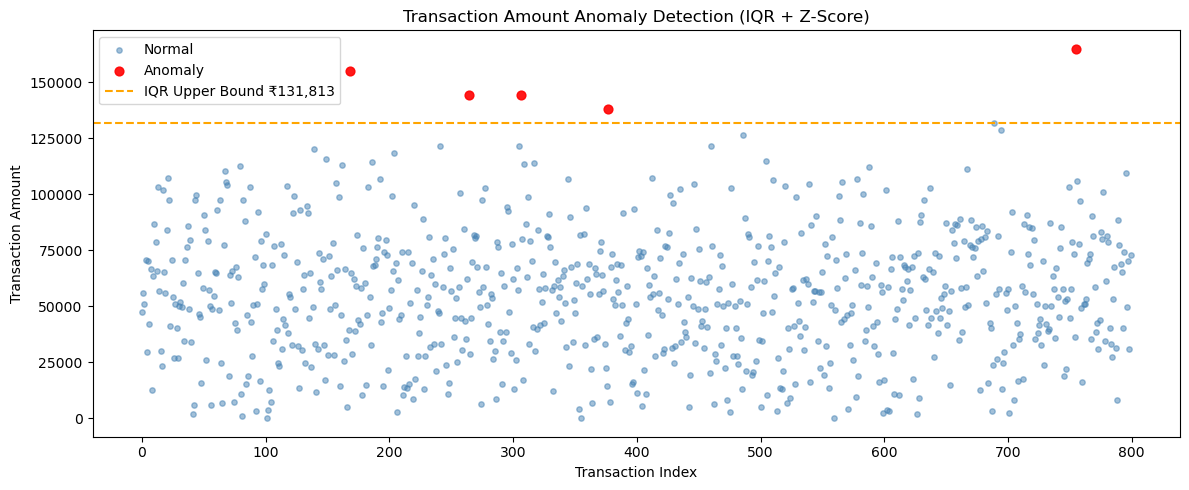

In [57]:
plt.figure(figsize=(12, 5))
plt.scatter(df[df['anomaly_flag'] == False].index,
            df[df['anomaly_flag'] == False]['transactionamount'],
            color='steelblue', alpha=0.5, label='Normal', s=15)
plt.scatter(df[df['anomaly_flag'] == True].index,
            df[df['anomaly_flag'] == True]['transactionamount'],
            color='red', alpha=0.9, label='Anomaly', s=40)
plt.axhline(upper_bound, color='orange', linestyle='--', label=f'IQR Upper Bound ₹{upper_bound:,.0f}')
plt.title('Transaction Amount Anomaly Detection (IQR + Z-Score)')
plt.xlabel('Transaction Index')
plt.ylabel('Transaction Amount')
plt.legend()
plt.tight_layout()
plt.show()

In [58]:
suspicion = df.groupby('accountid').agg(
    anomaly=('anomaly_flag', 'any'),
    frequent_large_withdrawal=('frequent_large_withdrawal_flag', 'any'),
    overdraft=('overdraft_flag', 'any'),
    high_volatility=('volatility_level', lambda x: (x == 'High').any()),
    dormant=('dormant_flag', 'any')
).reset_index()

suspicion['suspicion_score'] = (
    suspicion['anomaly'].astype(int) * 2 +
    suspicion['frequent_large_withdrawal'].astype(int) * 2 +
    suspicion['overdraft'].astype(int) * 2 +
    suspicion['high_volatility'].astype(int) * 1 +
    suspicion['dormant'].astype(int) * 1
)

print(suspicion['suspicion_score'].describe())

count    192.000000
mean       1.468750
std        1.166308
min        0.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        8.000000
Name: suspicion_score, dtype: float64


In [59]:
def classify_suspicion(score):
    if score >= 4:
        return 'High'
    elif score >= 2:
        return 'Medium'
    else:
        return 'Low'

suspicion['suspicion_level'] = suspicion['suspicion_score'].apply(classify_suspicion)
print(suspicion['suspicion_level'].value_counts())

suspicion_level
Low       141
Medium     30
High       21
Name: count, dtype: int64


In [60]:
high_suspicion = suspicion[suspicion['suspicion_level'] == 'High'].sort_values('suspicion_score', ascending=False)
print(f"Total High Suspicion Accounts: {len(high_suspicion)}")
print(high_suspicion.to_string(index=False))

Total High Suspicion Accounts: 21
accountid  anomaly  frequent_large_withdrawal  overdraft  high_volatility  dormant  suspicion_score suspicion_level
 ACC45101     True                       True       True             True     True                8            High
 ACC11062    False                      False       True             True     True                4            High
 ACC64022    False                      False       True             True     True                4            High
 ACC94907    False                      False       True             True     True                4            High
 ACC88516    False                      False       True             True     True                4            High
 ACC88252    False                      False       True             True     True                4            High
 ACC87602    False                      False       True             True     True                4            High
 ACC78589    False                    

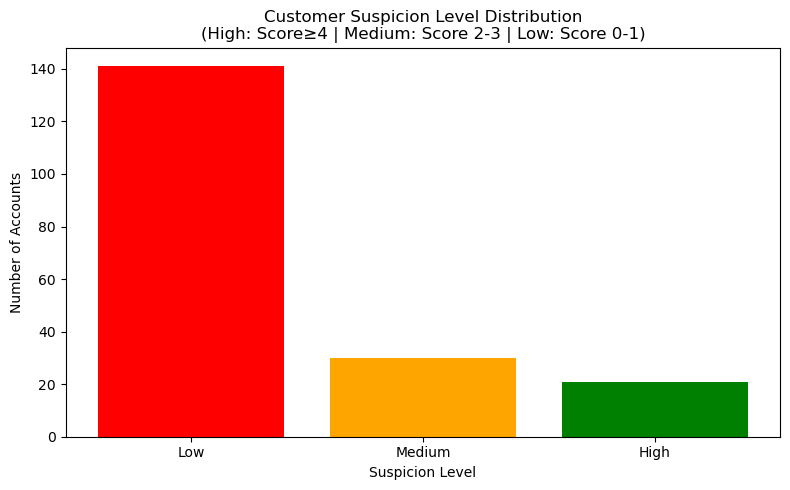

In [61]:
suspicion_counts = suspicion['suspicion_level'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(suspicion_counts.index, suspicion_counts.values, color=['red', 'orange', 'green'])
plt.title('Customer Suspicion Level Distribution\n(High: Score≥4 | Medium: Score 2-3 | Low: Score 0-1)')
plt.xlabel('Suspicion Level')
plt.ylabel('Number of Accounts')
plt.tight_layout()
plt.show()

Task 5: Visualization

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print("Style set!")

Style set!


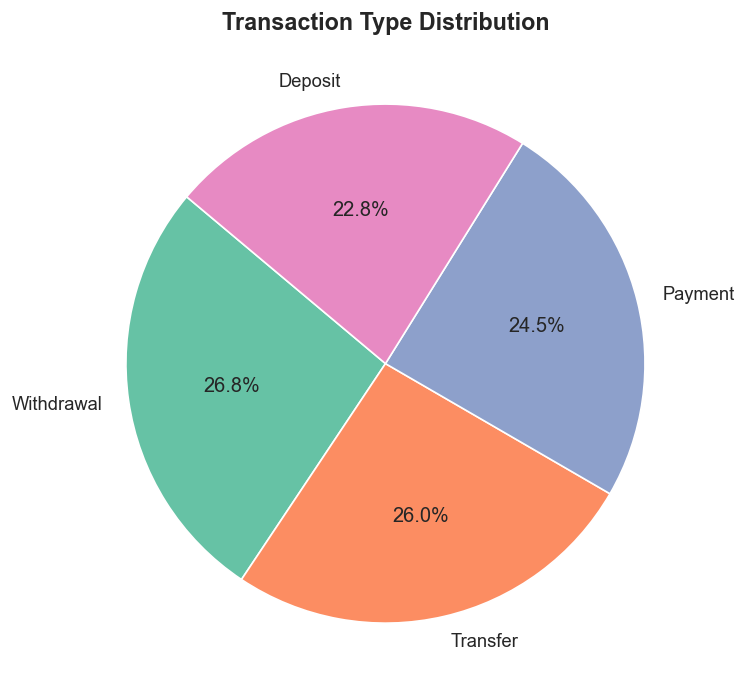

In [63]:
plt.figure(figsize=(8, 6))
txn_counts = df['transactiontype'].value_counts()
plt.pie(txn_counts.values, labels=txn_counts.index, autopct='%1.1f%%',
        colors=sns.color_palette('Set2', len(txn_counts)), startangle=140)
plt.title('Transaction Type Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\Ayush\AppData\Local\Temp\ipykernel_114008\1054561303.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_bal.index, y=avg_bal.values, palette='Blues_d')


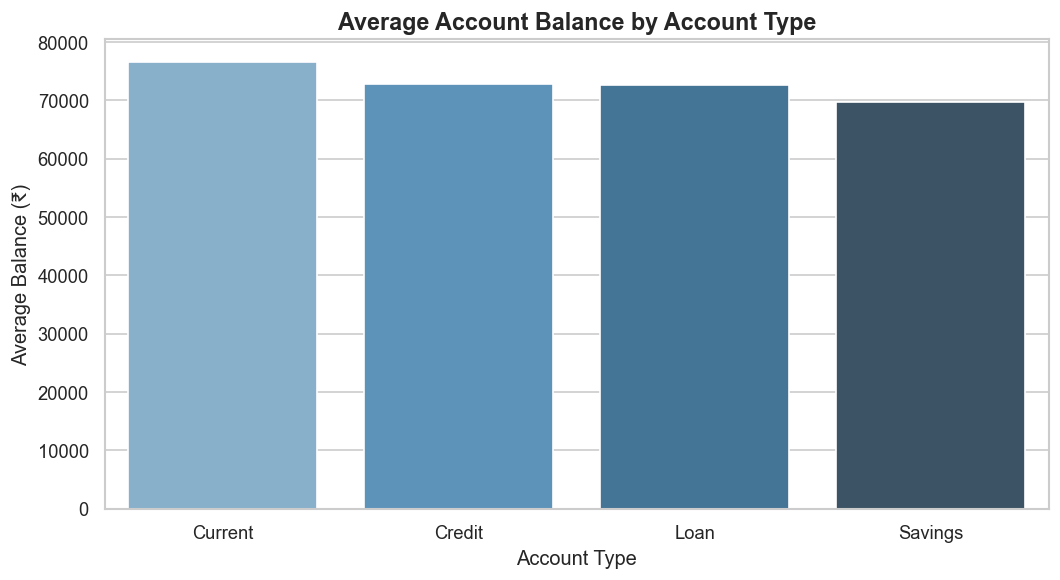

In [64]:
plt.figure(figsize=(9, 5))
avg_bal = df.groupby('accounttype')['accountbalance'].mean().sort_values(ascending=False)
sns.barplot(x=avg_bal.index, y=avg_bal.values, palette='Blues_d')
plt.title('Average Account Balance by Account Type', fontsize=14, fontweight='bold')
plt.xlabel('Account Type')
plt.ylabel('Average Balance (₹)')
plt.tight_layout()
plt.show()

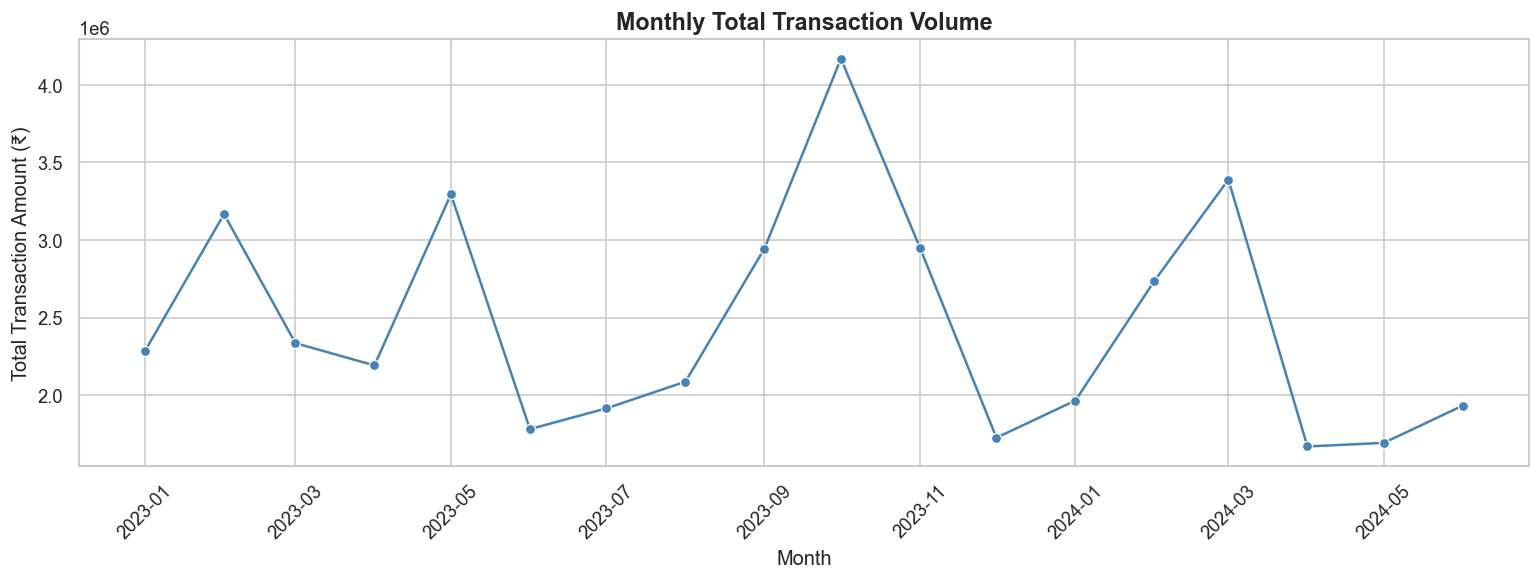

In [65]:
monthly_vol = df.groupby(['transaction_year', 'transaction_month'])['transactionamount'].sum().reset_index()
monthly_vol['period'] = pd.to_datetime(monthly_vol[['transaction_year','transaction_month']].assign(day=1).rename(columns={'transaction_year':'year','transaction_month':'month'}))

plt.figure(figsize=(13, 5))
sns.lineplot(data=monthly_vol, x='period', y='transactionamount', marker='o', color='steelblue')
plt.title('Monthly Total Transaction Volume', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Transaction Amount (₹)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\Ayush\AppData\Local\Temp\ipykernel_114008\3240198177.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='accounttype', y='riskscore', palette='Set3')


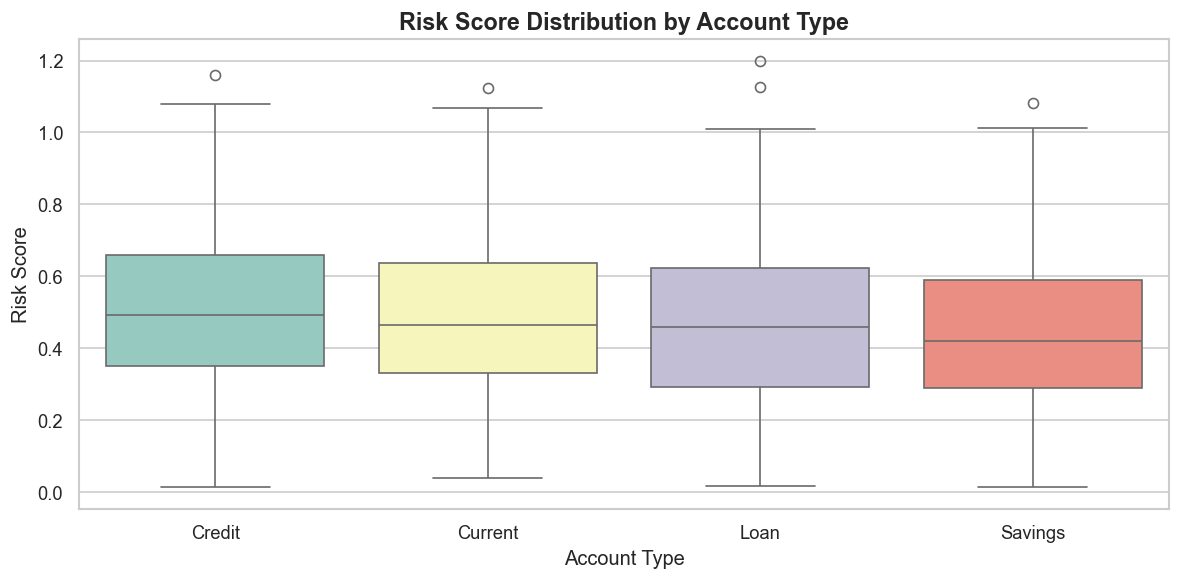

In [66]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='accounttype', y='riskscore', palette='Set3')
plt.title('Risk Score Distribution by Account Type', fontsize=14, fontweight='bold')
plt.xlabel('Account Type')
plt.ylabel('Risk Score')
plt.tight_layout()
plt.show()

C:\Users\Ayush\AppData\Local\Temp\ipykernel_114008\1347192897.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_txn.index, y=region_txn.values, palette='coolwarm')


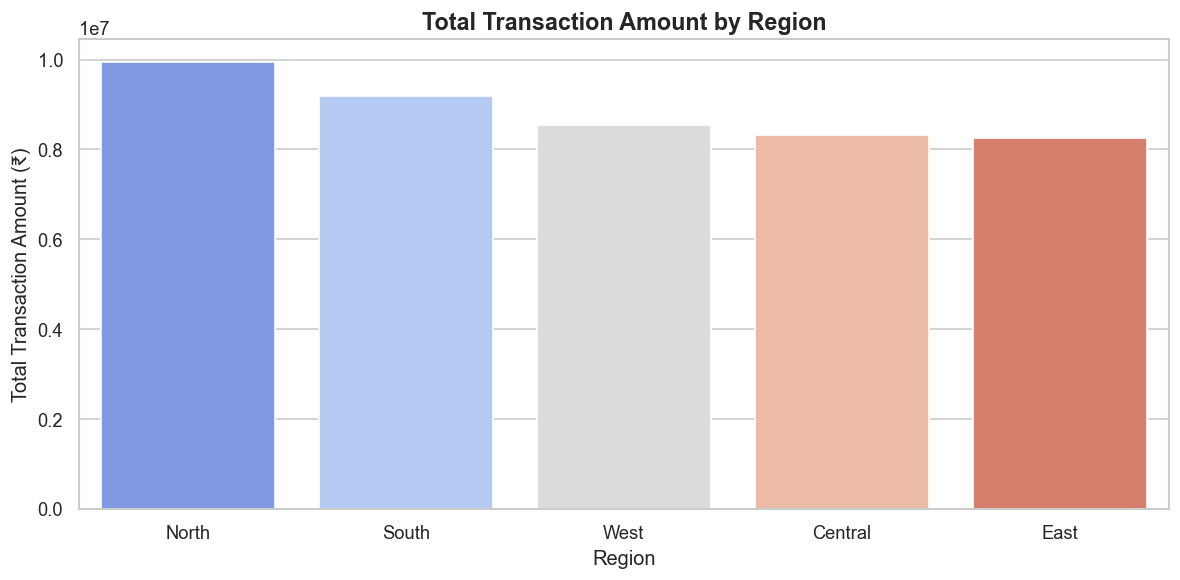

In [67]:
plt.figure(figsize=(10, 5))
region_txn = df.groupby('region')['transactionamount'].sum().sort_values(ascending=False)
sns.barplot(x=region_txn.index, y=region_txn.values, palette='coolwarm')
plt.title('Total Transaction Amount by Region', fontsize=14, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Total Transaction Amount (₹)')
plt.tight_layout()
plt.show()

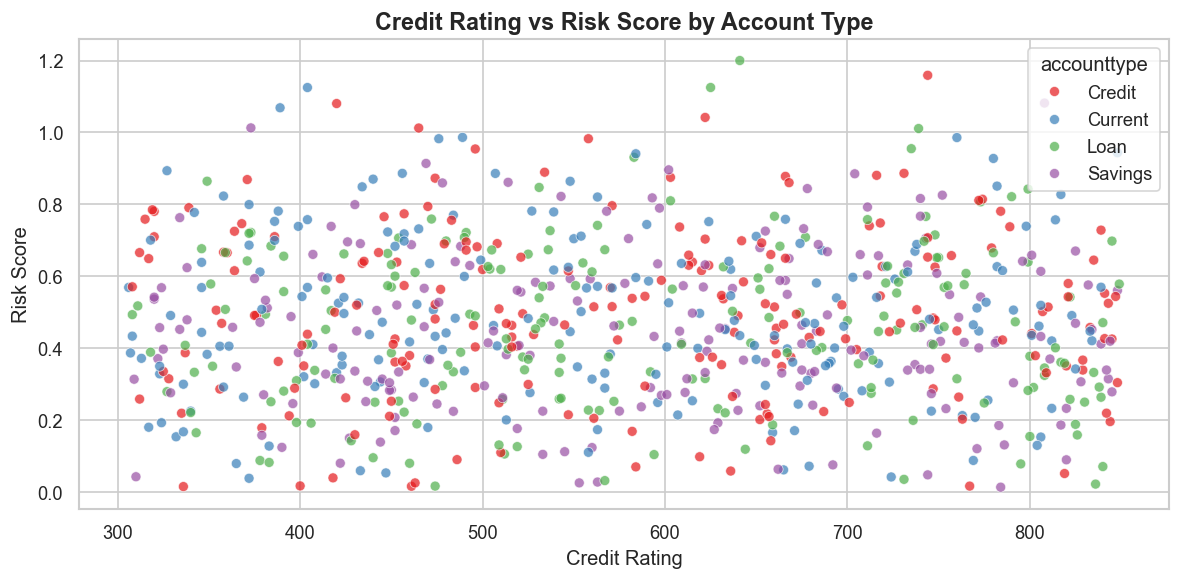

In [68]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='creditrating', y='riskscore',
                hue='accounttype', palette='Set1', alpha=0.7)
plt.title('Credit Rating vs Risk Score by Account Type', fontsize=14, fontweight='bold')
plt.xlabel('Credit Rating')
plt.ylabel('Risk Score')
plt.tight_layout()
plt.show()

C:\Users\Ayush\AppData\Local\Temp\ipykernel_114008\4127776774.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='segment', palette='Set2',


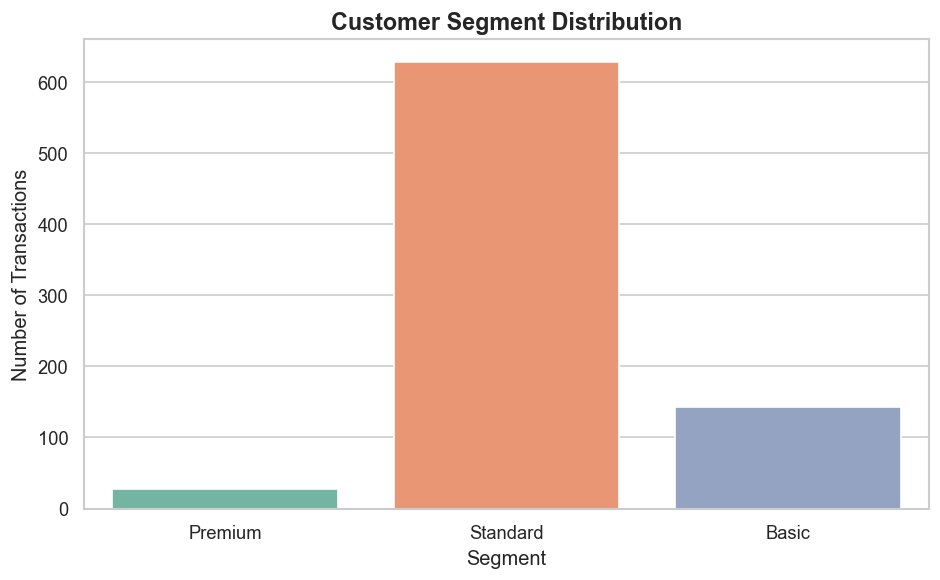

In [69]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='segment', palette='Set2',
              order=['Premium', 'Standard', 'Basic'])
plt.title('Customer Segment Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

C:\Users\Ayush\AppData\Local\Temp\ipykernel_114008\3334603779.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_susp, x='suspicion_level', y='accountbalance',


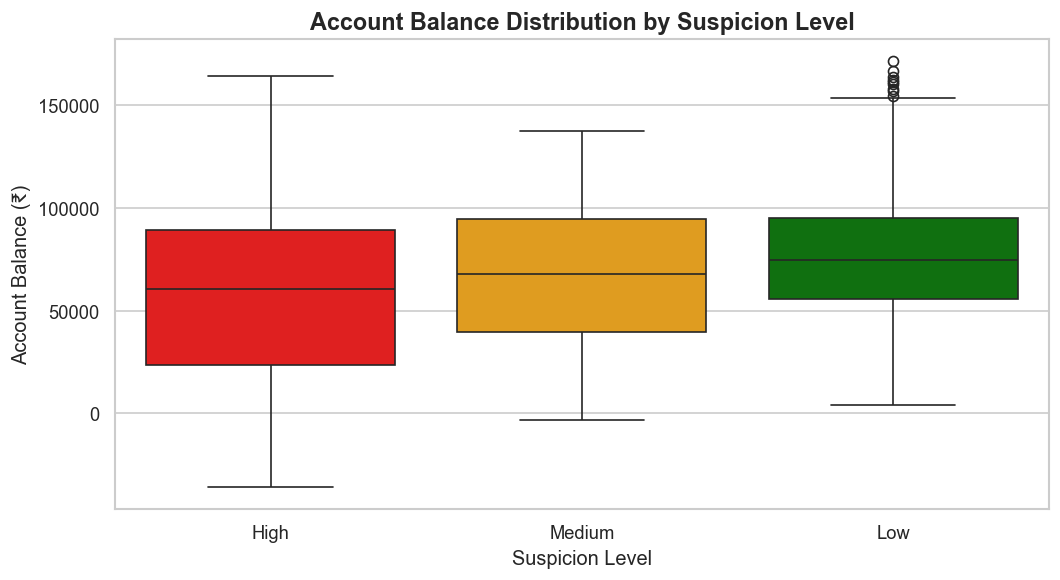

In [70]:
df_susp = df.merge(suspicion[['accountid','suspicion_level']], on='accountid', how='left')

plt.figure(figsize=(9, 5))
sns.boxplot(data=df_susp, x='suspicion_level', y='accountbalance',
            order=['High','Medium','Low'], palette=['red','orange','green'])
plt.title('Account Balance Distribution by Suspicion Level', fontsize=14, fontweight='bold')
plt.xlabel('Suspicion Level')
plt.ylabel('Account Balance (₹)')
plt.tight_layout()
plt.show()

Task 6: Hypothesis Testing

In [71]:
from scipy import stats

high_volume = df[df['activity_level'] == 'High']['accountbalance']
low_volume  = df[df['activity_level'] == 'Low']['accountbalance']

print(f"High Volume Accounts — Count: {len(high_volume)}, Mean Balance: ₹{high_volume.mean():,.2f}")
print(f"Low Volume Accounts  — Count: {len(low_volume)},  Mean Balance: ₹{low_volume.mean():,.2f}")

High Volume Accounts — Count: 321, Mean Balance: ₹71,541.72
Low Volume Accounts  — Count: 76,  Mean Balance: ₹84,088.33


In [72]:
stat_high, p_high = stats.shapiro(high_volume)
stat_low,  p_low  = stats.shapiro(low_volume)

print(f"Shapiro-Wilk Test — High Volume: stat={stat_high:.4f}, p={p_high:.4f}")
print(f"Shapiro-Wilk Test — Low Volume : stat={stat_low:.4f},  p={p_low:.4f}")

if p_high > 0.05 and p_low > 0.05:
    print("\nBoth groups are normally distributed → T-Test is appropriate")
else:
    print("\nOne or both groups are NOT normally distributed → Mann-Whitney U Test will be used as backup")

Shapiro-Wilk Test — High Volume: stat=0.9948, p=0.3441
Shapiro-Wilk Test — Low Volume : stat=0.9881,  p=0.7020

Both groups are normally distributed → T-Test is appropriate


In [73]:
t_stat, p_two_tailed = stats.ttest_ind(high_volume, low_volume, alternative='greater')
p_one_tailed = p_two_tailed

print(f"T-Statistic : {t_stat:.4f}")
print(f"P-Value     : {p_one_tailed:.4f}")
print()
if p_one_tailed < 0.05:
    print("Result: REJECT H₀ → High-volume accounts have statistically HIGHER average balances than low-volume accounts")
else:
    print("Result: FAIL TO REJECT H₀ → No statistically significant difference found")

T-Statistic : -2.9372
P-Value     : 0.9982

Result: FAIL TO REJECT H₀ → No statistically significant difference found


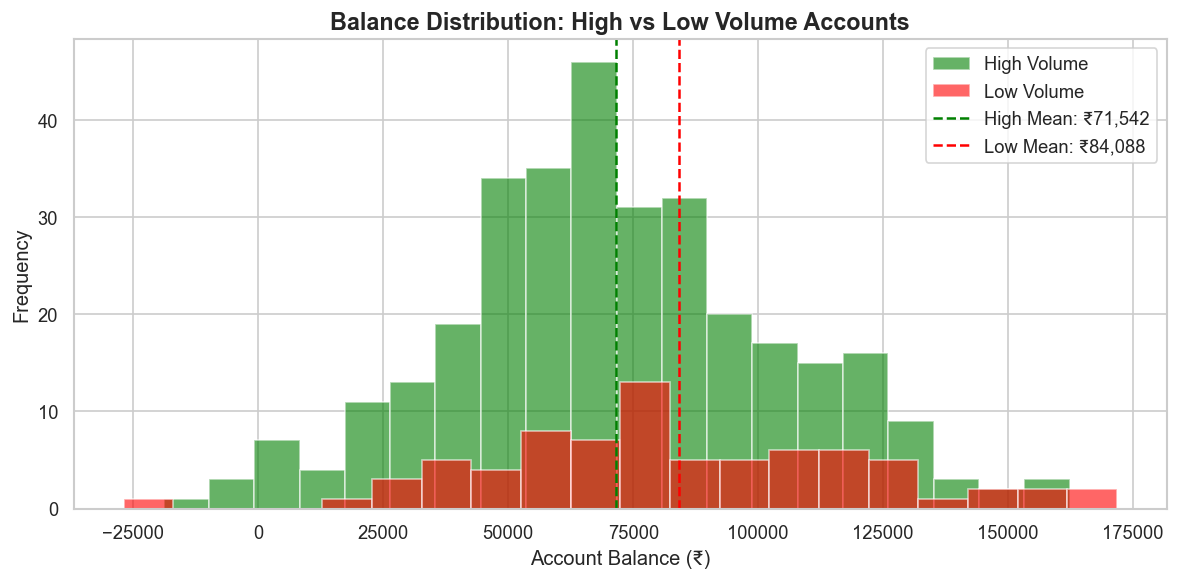

In [74]:
plt.figure(figsize=(10, 5))
plt.hist(high_volume, bins=20, alpha=0.6, color='green', label='High Volume')
plt.hist(low_volume,  bins=20, alpha=0.6, color='red',   label='Low Volume')
plt.axvline(high_volume.mean(), color='green', linestyle='--', label=f'High Mean: ₹{high_volume.mean():,.0f}')
plt.axvline(low_volume.mean(),  color='red',   linestyle='--', label=f'Low Mean: ₹{low_volume.mean():,.0f}')
plt.title('Balance Distribution: High vs Low Volume Accounts', fontsize=14, fontweight='bold')
plt.xlabel('Account Balance (₹)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

In [75]:
premium  = df[df['segment'] == 'Premium']['accountbalance']
standard = df[df['segment'] == 'Standard']['accountbalance']
basic    = df[df['segment'] == 'Basic']['accountbalance']

print(f"Premium  — Count: {len(premium)},  Mean Balance: ₹{premium.mean():,.2f}")
print(f"Standard — Count: {len(standard)}, Mean Balance: ₹{standard.mean():,.2f}")
print(f"Basic    — Count: {len(basic)},    Mean Balance: ₹{basic.mean():,.2f}")

Premium  — Count: 28,  Mean Balance: ₹99,115.33
Standard — Count: 629, Mean Balance: ₹74,489.11
Basic    — Count: 143,    Mean Balance: ₹61,040.65


In [76]:
for segment, data in [('Premium', premium), ('Standard', standard), ('Basic', basic)]:
    stat, p = stats.shapiro(data)
    print(f"Shapiro-Wilk — {segment}: stat={stat:.4f}, p={p:.4f} → {'Normal ✅' if p > 0.05 else 'Not Normal ❌'}")

Shapiro-Wilk — Premium: stat=0.9638, p=0.4273 → Normal ✅
Shapiro-Wilk — Standard: stat=0.9979, p=0.6467 → Normal ✅
Shapiro-Wilk — Basic: stat=0.9904, p=0.4357 → Normal ✅


In [77]:
f_stat, p_value = stats.f_oneway(premium, standard, basic)

print(f"F-Statistic : {f_stat:.4f}")
print(f"P-Value     : {p_value:.6f}")
print()
if p_value < 0.05:
    print("Result: REJECT H₀ → Statistically significant difference exists between segment balances")
else:
    print("Result: FAIL TO REJECT H₀ → No statistically significant difference between segment balances")

F-Statistic : 18.2511
P-Value     : 0.000000

Result: REJECT H₀ → Statistically significant difference exists between segment balances


In [78]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey_data   = df['accountbalance']
tukey_groups = df['segment']

tukey_result = pairwise_tukeyhsd(tukey_data, tukey_groups, alpha=0.05)
print(tukey_result)

       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
 group1  group2    meandiff  p-adj     lower      upper    reject
-----------------------------------------------------------------
  Basic  Premium  38074.6863    0.0  21823.3165 54326.0561   True
  Basic Standard  13448.4566    0.0   6163.0422  20733.871   True
Premium Standard -24626.2297 0.0004 -39814.8141 -9437.6454   True
-----------------------------------------------------------------


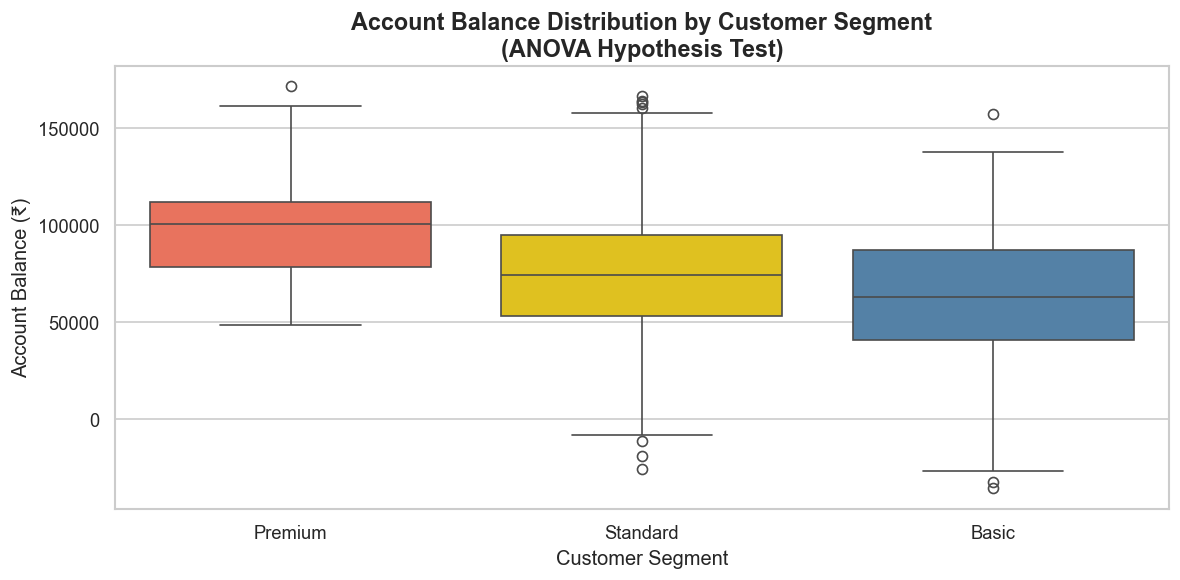

In [79]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='segment', y='accountbalance',
            hue='segment', order=['Premium','Standard','Basic'],
            palette=['gold','steelblue','tomato'], legend=False)
plt.title('Account Balance Distribution by Customer Segment\n(ANOVA Hypothesis Test)', fontsize=14, fontweight='bold')
plt.xlabel('Customer Segment')
plt.ylabel('Account Balance (₹)')
plt.tight_layout()
plt.show()